In [55]:
from pathlib import Path
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

CSV_PATTERN = "hashjoin_*.csv"
RESULTS_CANDIDATES = [
    Path("results"),
    Path("src/results"),
    Path("../results"),
]

RESULTS_DIR = None
csv_files = []
for candidate_dir in RESULTS_CANDIDATES:
    candidate_files = sorted(candidate_dir.glob(CSV_PATTERN))
    if candidate_files:
        RESULTS_DIR = candidate_dir
        csv_files = candidate_files
        break

if not csv_files or RESULTS_DIR is None:
    searched = ", ".join(str(p) for p in RESULTS_CANDIDATES)
    raise FileNotFoundError(f"No CSV files found with pattern {CSV_PATTERN} in: {searched}")

frames = []
for csv_path in csv_files:
    current_df = pd.read_csv(csv_path)
    current_df["exec_type"] = csv_path.stem.replace("hashjoin_", "", 1)
    frames.append(current_df)

df = pd.concat(frames, ignore_index=True, sort=False)

# Keep schedule columns as strings; converting them to numeric would turn "static" into NaN.
numeric_columns = [
    "checksum1",
    "checksum2",
    "join_count",
    "join_threads",
    "join_throughput",
    "join_time",
    "max_key",
    "nr",
    "ns",
    "partition_threads",
    "partition_throughput",
    "partition_time",
    "time_sec",
    "total_throughput",
    "partition_chunk",
    "join_chunk",
    "partition_block_size",
]
for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

fallback_total_throughput = (df["nr"] + df["ns"]) / df["time_sec"].where(df["time_sec"] > 0)
if "total_throughput" not in df.columns:
    df["total_throughput"] = fallback_total_throughput
else:
    df["total_throughput"] = df["total_throughput"].fillna(fallback_total_throughput)

exec_type_names = sorted(df["exec_type"].dropna().unique())
exec_type_palette = [
    "tab:blue",
    "tab:orange",
    "tab:green",
    "tab:red",
    "tab:purple",
    "tab:brown",
    "tab:pink",
    "tab:gray",
    "tab:olive",
    "tab:cyan",
]
color_map = {
    exec_type: exec_type_palette[idx % len(exec_type_palette)]
    for idx, exec_type in enumerate(exec_type_names)
}


def apply_tone(base_color, tone_strength):
    """Blend a base color with white; tone_strength=1 keeps the base color."""
    strength = float(max(0.0, min(1.0, tone_strength)))
    base_rgb = mcolors.to_rgb(base_color)
    toned_rgb = tuple(1.0 - strength * (1.0 - channel) for channel in base_rgb)
    return mcolors.to_hex(toned_rgb)


def build_tone_strength_map(values, min_strength=0.45, max_strength=1.0):
    ordered = sorted(values)
    if not ordered:
        return {}
    if len(ordered) == 1:
        return {ordered[0]: float(max_strength)}
    min_s = float(min_strength)
    max_s = float(max_strength)
    span = max_s - min_s
    return {
        value: min_s + span * idx / (len(ordered) - 1)
        for idx, value in enumerate(ordered)
    }


def resolve_img_dir():
    candidates = [
        Path("src/img"),
        Path("img"),
        Path("../src/img"),
        Path("../img"),
    ]
    for candidate in candidates:
        if candidate.parent.exists() or candidate.exists():
            candidate.mkdir(parents=True, exist_ok=True)
            return candidate
    fallback = Path("img")
    fallback.mkdir(parents=True, exist_ok=True)
    return fallback


IMG_DIR = resolve_img_dir()
PLOT_SAVE_COUNTER = 0


def slugify(value):
    cleaned = re.sub(r"[^A-Za-z0-9._-]+", "_", str(value)).strip("_")
    if not cleaned:
        return "plot"
    return cleaned[:180]


def save_figure(fig, name_prefix):
    global PLOT_SAVE_COUNTER
    PLOT_SAVE_COUNTER += 1
    filename = f"{PLOT_SAVE_COUNTER:03d}_{slugify(name_prefix)}.png"
    output_path = IMG_DIR / filename
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    print(f"[saved] {output_path}")


def show_and_save(fig, name_prefix):
    save_figure(fig, name_prefix)
    plt.show()
    plt.close(fig)


print(f"[Loaded {df.shape[0]} runs from {RESULTS_DIR}]\n")
print("Files:")
for csv_path in csv_files:
    print(f"  - {csv_path.name}")

print("\nDistinct values:")
print(f"  exec_type: {exec_type_names}")
print(f"  max_key: {sorted(df['max_key'].dropna().unique())}")
print(f"  partition_threads: {sorted(df['partition_threads'].dropna().unique())}")
print(f"  join_threads: {sorted(df['join_threads'].dropna().unique())}")
print(f"  image_output_dir: {IMG_DIR}")


def _as_2d_axes(axes, nrows, ncols):
    if nrows == 1 and ncols == 1:
        return [[axes]]
    if nrows == 1:
        return [list(axes)]
    if ncols == 1:
        return [[ax] for ax in axes]
    return axes


def plot_thread_matrix(metric_df, metric_col, y_label, title_prefix, global_ymax=None, hline=None):
    required_cols = {
        "nr",
        "ns",
        "max_key",
        "partition_threads",
        "join_threads",
        "exec_type",
        metric_col,
    }
    missing_cols = sorted(required_cols - set(metric_df.columns))
    if missing_cols:
        print(f"Skipping {metric_col}: missing columns {missing_cols}")
        return

    for (fixed_nr, fixed_ns, fixed_max_key), subdf in metric_df.groupby(["nr", "ns", "max_key"]):
        part_values = sorted(subdf["partition_threads"].dropna().unique())
        join_values = sorted(subdf["join_threads"].dropna().unique())

        seq_ref = subdf[subdf["exec_type"] == "seq"]
        seq_value = (
            float(seq_ref[metric_col].mean())
            if not seq_ref.empty and pd.notna(seq_ref[metric_col].mean())
            else float("nan")
        )

        if pd.notna(seq_value):
            if 1 not in part_values:
                part_values = [1] + part_values
            if 1 not in join_values:
                join_values = [1] + join_values

        other_exec_types = sorted([e for e in subdf["exec_type"].dropna().unique() if e != "seq"])
        exec_types = (["seq"] if pd.notna(seq_value) else []) + other_exec_types

        if not exec_types or not part_values or not join_values:
            continue

        value_lookup = (
            subdf.dropna(subset=["partition_threads", "join_threads"])
            .set_index(["exec_type", "partition_threads", "join_threads"])[metric_col]
            .to_dict()
        )

        nrows = len(join_values)
        ncols = len(part_values)
        fig, axes = plt.subplots(
            nrows,
            ncols,
            figsize=(max(3.2 * ncols, 8), max(2.6 * nrows, 6)),
            sharey=True,
        )
        axes_2d = _as_2d_axes(axes, nrows, ncols)

        for r, join_threads in enumerate(join_values):
            for c, part_threads in enumerate(part_values):
                ax = axes_2d[r][c]

                heights = []
                for exec_type in exec_types:
                    if exec_type == "seq":
                        value = seq_value if (part_threads == 1 and join_threads == 1) else float("nan")
                    else:
                        value = value_lookup.get((exec_type, part_threads, join_threads), float("nan"))
                    heights.append(value)

                x_positions = list(range(len(exec_types)))
                colors = [color_map.get(exec_type, "tab:gray") for exec_type in exec_types]
                ax.bar(x_positions, heights, color=colors)

                if pd.notna(global_ymax) and global_ymax > 0:
                    ax.set_ylim(0, global_ymax * 1.05)

                if hline is not None:
                    ax.axhline(float(hline), color="black", linestyle=":", linewidth=1.0, alpha=0.8)

                ax.set_xticks(x_positions)
                ax.set_xticklabels(exec_types, rotation=45, ha="right", fontsize=8)

                if r == 0:
                    ax.set_title(f"partition_threads={int(part_threads)}", fontsize=9)
                if c == 0:
                    ax.set_ylabel(f"join_threads={int(join_threads)}\n{y_label}", fontsize=8)

                ax.grid(axis="y", alpha=0.25)

        fig.suptitle(
            f"{title_prefix} matrix (nr={int(fixed_nr)}, ns={int(fixed_ns)}, max_key={int(fixed_max_key)})",
            y=1.02,
        )
        fig.tight_layout()
        show_and_save(
            fig,
            f"{title_prefix}_matrix_nr{int(fixed_nr)}_ns{int(fixed_ns)}_maxkey{int(fixed_max_key)}",
        )


[Loaded 293 runs from results]

Files:
  - hashjoin_omp_loop.csv
  - hashjoin_seq.csv

Distinct values:
  exec_type: ['omp_loop', 'seq']
  max_key: [1000000]
  partition_threads: [1, 16, 32, 64]
  join_threads: [1, 16, 32, 64]
  image_output_dir: img


# Checksum validation

In [56]:
checksum_group_cols = ["nr", "ns", "max_key"]
summary_rows = []

for (nr, ns, max_key), subdf in df.groupby(checksum_group_cols):
    checksum_pairs = subdf[["checksum1", "checksum2"]].drop_duplicates()
    summary_rows.append({
        "nr": nr,
        "ns": ns,
        "max_key": max_key,
        "n_distinct_checksum_pairs": len(checksum_pairs),
        "is_valid": len(checksum_pairs) == 1,
        "exec_types": ", ".join(sorted(subdf["exec_type"].dropna().unique())),
    })

checksum_validation_df = (
    pd.DataFrame(summary_rows)
    .sort_values(checksum_group_cols)
    .reset_index(drop=True)
)

valid_groups = int(checksum_validation_df["is_valid"].sum()) if not checksum_validation_df.empty else 0
print(f"[OK groups: {valid_groups}/{len(checksum_validation_df)}]")
checksum_validation_df


[OK groups: 2/2]


,nr,ns,max_key,n_distinct_checksum_pairs,is_valid,exec_types
0,10000000,10000000,1000000,1,True,omp_loop
1,50000000,50000000,1000000,1,True,seq


# Averaging

In [57]:
group_columns = [
    "checksum1",
    "checksum2",
    "nr",
    "ns",
    "max_key",
    "exec_type",
    "join_count",
    "join_threads",
    "partition_threads",
    "partition_schedule",
    "join_schedule",
    "partition_chunk",
    "join_chunk",
    "partition_block_size",
]

# Average every numeric field that is not part of the run-parameter key above.
avg_columns = [
    col for col in df.columns
    if col not in group_columns and pd.api.types.is_numeric_dtype(df[col])
]

# dropna=False keeps seq rows, which do not have the OpenMP-only tuning columns.
stable_avg_df = (
    df.groupby(group_columns, as_index=False, dropna=False)
    .agg({col: "mean" for col in avg_columns})
    .sort_values(group_columns)
    .reset_index(drop=True)
)

print(f"non_averaged={df.shape}\n\t{df.columns}")
display(df.head(5))
print(f"averaged={stable_avg_df.shape}\n\t{stable_avg_df.columns}")
display(stable_avg_df.head(5))

non_averaged=(293, 20)
	Index(['checksum1', 'checksum2', 'join_chunk', 'join_count', 'join_schedule',
       'join_threads', 'join_throughput', 'join_time', 'max_key', 'nr', 'ns',
       'partition_block_size', 'partition_chunk', 'partition_schedule',
       'partition_threads', 'partition_throughput', 'partition_time',
       'time_sec', 'total_throughput', 'exec_type'],
      dtype='object')


,checksum1,checksum2,join_chunk,join_count,join_schedule,join_threads,join_throughput,join_time,max_key,nr,ns,partition_block_size,partition_chunk,partition_schedule,partition_threads,partition_throughput,partition_time,time_sec,total_throughput,exec_type
0,7970473340851283408,15465518843320288240,0.0,99994796,static,16,5.321881e+08,0.037581,1000000,10000000,10000000,32768.0,0.0,static,16,2.346947e+08,0.085217,0.123527,1.619074e+08,omp_loop
1,7970473340851283408,15465518843320288240,0.0,99994796,static,16,5.046175e+08,0.039634,1000000,10000000,10000000,131072.0,0.0,static,16,2.332849e+08,0.085732,0.126099,1.586061e+08,omp_loop
2,7970473340851283408,15465518843320288240,32.0,99994796,static,16,2.732197e+08,0.073201,1000000,10000000,10000000,32768.0,0.0,static,16,2.339305e+08,0.085495,0.159419,1.254557e+08,omp_loop
3,7970473340851283408,15465518843320288240,32.0,99994796,static,16,2.762530e+08,0.072397,1000000,10000000,10000000,131072.0,0.0,static,16,2.323704e+08,0.086069,0.159177,1.256465e+08,omp_loop
4,7970473340851283408,15465518843320288240,0.0,99994796,static,16,5.213975e+08,0.038358,1000000,10000000,10000000,32768.0,32.0,static,16,1.925830e+08,0.103851,0.142948,1.399115e+08,omp_loop


averaged=(289, 20)
	Index(['checksum1', 'checksum2', 'nr', 'ns', 'max_key', 'exec_type',
       'join_count', 'join_threads', 'partition_threads', 'partition_schedule',
       'join_schedule', 'partition_chunk', 'join_chunk',
       'partition_block_size', 'join_throughput', 'join_time',
       'partition_throughput', 'partition_time', 'time_sec',
       'total_throughput'],
      dtype='object')


,checksum1,checksum2,nr,ns,max_key,exec_type,join_count,join_threads,partition_threads,partition_schedule,join_schedule,partition_chunk,join_chunk,partition_block_size,join_throughput,join_time,partition_throughput,partition_time,time_sec,total_throughput
0,6185417096973469475,16931092769743058723,50000000,50000000,1000000,seq,2499986166,1,1,NaN,NaN,NaN,NaN,NaN,4.320027e+07,2.328505,5.157712e+07,1.938928,4.269839,2.345851e+07
1,7970473340851283408,15465518843320288240,10000000,10000000,1000000,omp_loop,99994796,16,16,dynamic,dynamic,0.0,0.0,32768.0,5.500081e+08,0.036363,2.392720e+08,0.083587,0.120602,1.658343e+08
2,7970473340851283408,15465518843320288240,10000000,10000000,1000000,omp_loop,99994796,16,16,dynamic,dynamic,0.0,0.0,131072.0,5.241828e+08,0.038155,2.421211e+08,0.082603,0.121493,1.646183e+08
3,7970473340851283408,15465518843320288240,10000000,10000000,1000000,omp_loop,99994796,16,16,dynamic,dynamic,0.0,32.0,32768.0,2.760222e+08,0.072458,2.385954e+08,0.083824,0.157186,1.272379e+08
4,7970473340851283408,15465518843320288240,10000000,10000000,1000000,omp_loop,99994796,16,16,dynamic,dynamic,0.0,32.0,131072.0,2.787979e+08,0.071737,2.397880e+08,0.083407,0.155900,1.282874e+08


# Partition time

[saved] img/001_partition_time_matrix_nr10000000_ns10000000_maxkey1000000.png


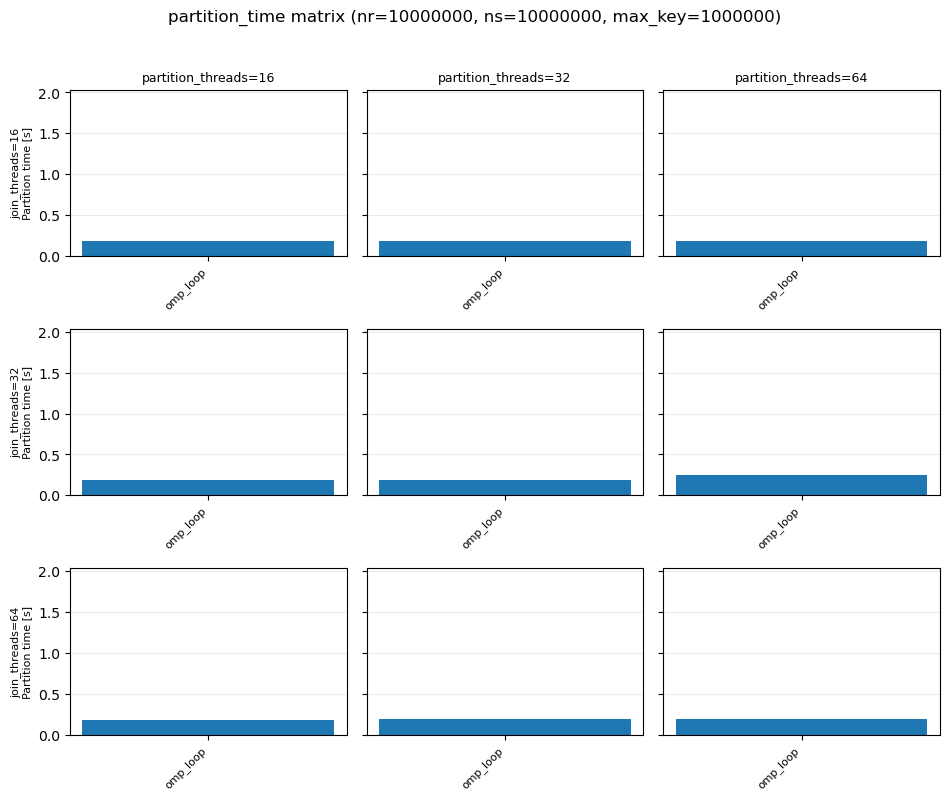

[saved] img/002_partition_time_matrix_nr50000000_ns50000000_maxkey1000000.png


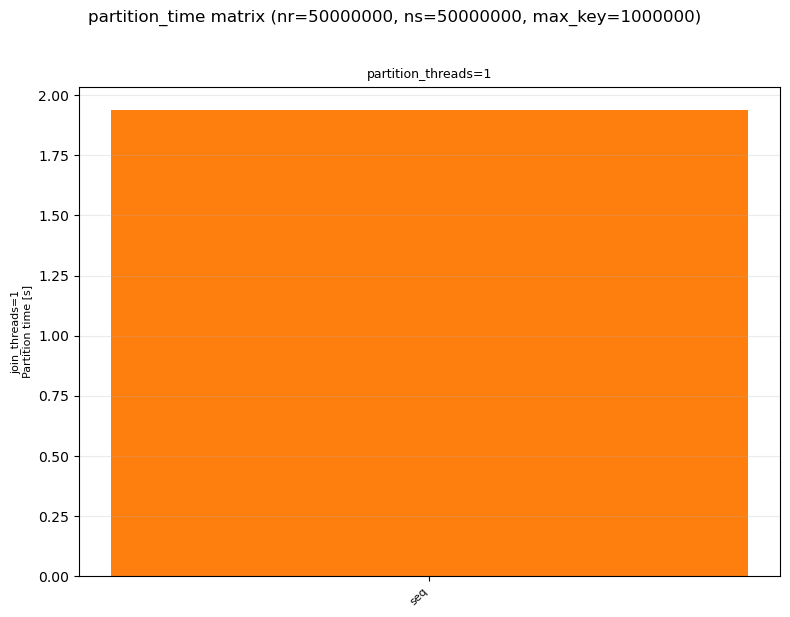

In [58]:
global_partition_time_ymax = stable_avg_df["partition_time"].max()
plot_thread_matrix(
    stable_avg_df,
    metric_col="partition_time",
    y_label="Partition time [s]",
    title_prefix="partition_time",
    global_ymax=global_partition_time_ymax,
)


# Partition time standard deviation

[saved] img/003_std_partition_time_by_max_key.png


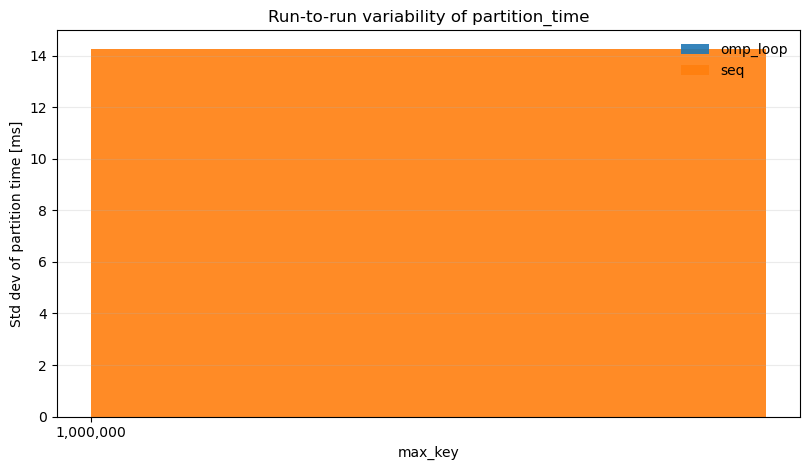

,checksum1,checksum2,join_chunk,join_count,join_schedule,join_threads,max_key,nr,ns,partition_block_size,partition_chunk,partition_schedule,partition_threads,exec_type,std_partition_time,std_ms
0,7970473340851283408,15465518843320288240,0.0,99994796,dynamic,16,1000000,10000000,10000000,32768.0,0.0,dynamic,16,omp_loop,NaN,NaN
1,7970473340851283408,15465518843320288240,0.0,99994796,dynamic,16,1000000,10000000,10000000,32768.0,0.0,dynamic,32,omp_loop,NaN,NaN
2,7970473340851283408,15465518843320288240,0.0,99994796,dynamic,16,1000000,10000000,10000000,32768.0,0.0,dynamic,64,omp_loop,NaN,NaN
3,7970473340851283408,15465518843320288240,0.0,99994796,dynamic,16,1000000,10000000,10000000,32768.0,0.0,static,16,omp_loop,NaN,NaN
4,7970473340851283408,15465518843320288240,0.0,99994796,dynamic,16,1000000,10000000,10000000,32768.0,0.0,static,32,omp_loop,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284,7970473340851283408,15465518843320288240,32.0,99994796,static,64,1000000,10000000,10000000,131072.0,32.0,dynamic,64,omp_loop,NaN,NaN
285,7970473340851283408,15465518843320288240,32.0,99994796,static,64,1000000,10000000,10000000,131072.0,32.0,static,16,omp_loop,NaN,NaN
286,7970473340851283408,15465518843320288240,32.0,99994796,static,64,1000000,10000000,10000000,131072.0,32.0,static,32,omp_loop,NaN,NaN
287,7970473340851283408,15465518843320288240,32.0,99994796,static,64,1000000,10000000,10000000,131072.0,32.0,static,64,omp_loop,NaN,NaN


In [59]:
std_df = (
    df.groupby([col for col in df.columns if col in group_columns], as_index=False, dropna=False)
    .agg(std_partition_time=("partition_time", "std"))
)
std_df["std_ms"] = std_df["std_partition_time"] * 1e3

max_key_values = sorted(std_df["max_key"].dropna().unique())
exec_types = sorted(std_df["exec_type"].dropna().unique())

x_positions = list(range(len(max_key_values)))
bar_width = 0.8 / len(exec_types) if exec_types else 0.8

fig, ax = plt.subplots(figsize=(8.2, 4.8))
for idx, exec_type in enumerate(exec_types):
    heights = []
    for max_key in max_key_values:
        sub = std_df[(std_df["max_key"] == max_key) & (std_df["exec_type"] == exec_type)]
        heights.append(float(sub["std_ms"].iloc[0]) if not sub.empty else float("nan"))

    offsets = [
        x + (idx - (len(exec_types) - 1) / 2) * bar_width
        for x in x_positions
    ]
    ax.bar(
        offsets,
        heights,
        width=bar_width,
        label=exec_type,
        color=color_map.get(exec_type, "tab:gray"),
        alpha=0.9,
    )

ax.set_xticks(x_positions)
ax.set_xticklabels([f"{int(v):,}" for v in max_key_values])
ax.set_xlabel("max_key")
ax.set_ylabel("Std dev of partition time [ms]")
ax.set_title("Run-to-run variability of partition_time")
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
show_and_save(fig, "std_partition_time_by_max_key")

std_df.sort_values(["max_key", "exec_type"]).reset_index(drop=True)


# Join time

[saved] img/004_join_time_matrix_nr10000000_ns10000000_maxkey1000000.png


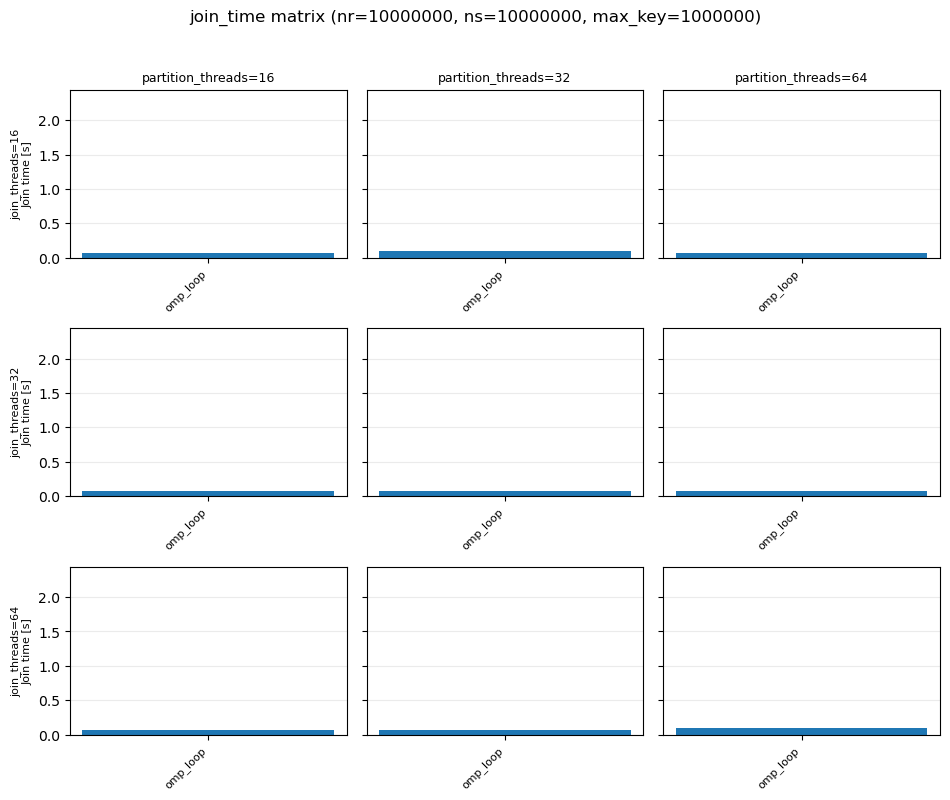

[saved] img/005_join_time_matrix_nr50000000_ns50000000_maxkey1000000.png


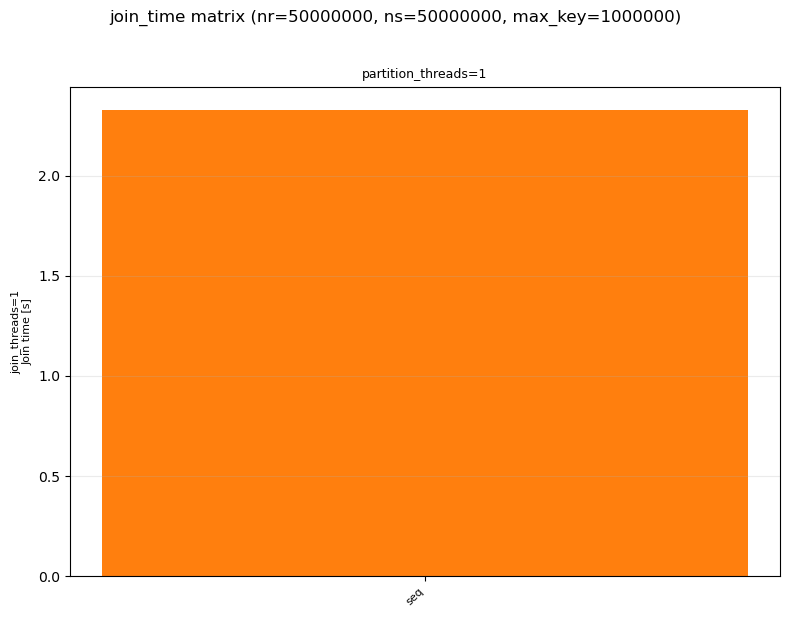

In [60]:
global_join_time_ymax = stable_avg_df["join_time"].max()
plot_thread_matrix(
    stable_avg_df,
    metric_col="join_time",
    y_label="Join time [s]",
    title_prefix="join_time",
    global_ymax=global_join_time_ymax,
)


# Join time standard deviation

[saved] img/006_std_join_time_by_max_key.png


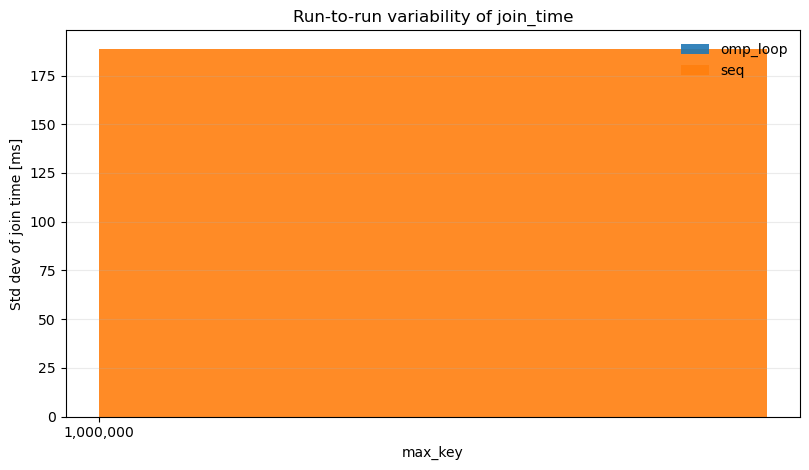

,checksum1,checksum2,join_chunk,join_count,join_schedule,join_threads,max_key,nr,ns,partition_block_size,partition_chunk,partition_schedule,partition_threads,exec_type,std_join_time,std_ms
0,7970473340851283408,15465518843320288240,0.0,99994796,dynamic,16,1000000,10000000,10000000,32768.0,0.0,dynamic,16,omp_loop,NaN,NaN
1,7970473340851283408,15465518843320288240,0.0,99994796,dynamic,16,1000000,10000000,10000000,32768.0,0.0,dynamic,32,omp_loop,NaN,NaN
2,7970473340851283408,15465518843320288240,0.0,99994796,dynamic,16,1000000,10000000,10000000,32768.0,0.0,dynamic,64,omp_loop,NaN,NaN
3,7970473340851283408,15465518843320288240,0.0,99994796,dynamic,16,1000000,10000000,10000000,32768.0,0.0,static,16,omp_loop,NaN,NaN
4,7970473340851283408,15465518843320288240,0.0,99994796,dynamic,16,1000000,10000000,10000000,32768.0,0.0,static,32,omp_loop,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284,7970473340851283408,15465518843320288240,32.0,99994796,static,64,1000000,10000000,10000000,131072.0,32.0,dynamic,64,omp_loop,NaN,NaN
285,7970473340851283408,15465518843320288240,32.0,99994796,static,64,1000000,10000000,10000000,131072.0,32.0,static,16,omp_loop,NaN,NaN
286,7970473340851283408,15465518843320288240,32.0,99994796,static,64,1000000,10000000,10000000,131072.0,32.0,static,32,omp_loop,NaN,NaN
287,7970473340851283408,15465518843320288240,32.0,99994796,static,64,1000000,10000000,10000000,131072.0,32.0,static,64,omp_loop,NaN,NaN


In [61]:
std_df = (
    df.groupby([col for col in df.columns if col in group_columns], as_index=False, dropna=False)
    .agg(std_join_time=("join_time", "std"))
)
std_df["std_ms"] = std_df["std_join_time"] * 1e3

max_key_values = sorted(std_df["max_key"].dropna().unique())
exec_types = sorted(std_df["exec_type"].dropna().unique())

x_positions = list(range(len(max_key_values)))
bar_width = 0.8 / len(exec_types) if exec_types else 0.8

fig, ax = plt.subplots(figsize=(8.2, 4.8))
for idx, exec_type in enumerate(exec_types):
    heights = []
    for max_key in max_key_values:
        sub = std_df[(std_df["max_key"] == max_key) & (std_df["exec_type"] == exec_type)]
        heights.append(float(sub["std_ms"].iloc[0]) if not sub.empty else float("nan"))

    offsets = [
        x + (idx - (len(exec_types) - 1) / 2) * bar_width
        for x in x_positions
    ]
    ax.bar(
        offsets,
        heights,
        width=bar_width,
        label=exec_type,
        color=color_map.get(exec_type, "tab:gray"),
        alpha=0.9,
    )

ax.set_xticks(x_positions)
ax.set_xticklabels([f"{int(v):,}" for v in max_key_values])
ax.set_xlabel("max_key")
ax.set_ylabel("Std dev of join time [ms]")
ax.set_title("Run-to-run variability of join_time")
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
show_and_save(fig, "std_join_time_by_max_key")

std_df.sort_values(["max_key", "exec_type"]).reset_index(drop=True)


# Total time

[saved] img/007_time_sec_matrix_nr10000000_ns10000000_maxkey1000000.png


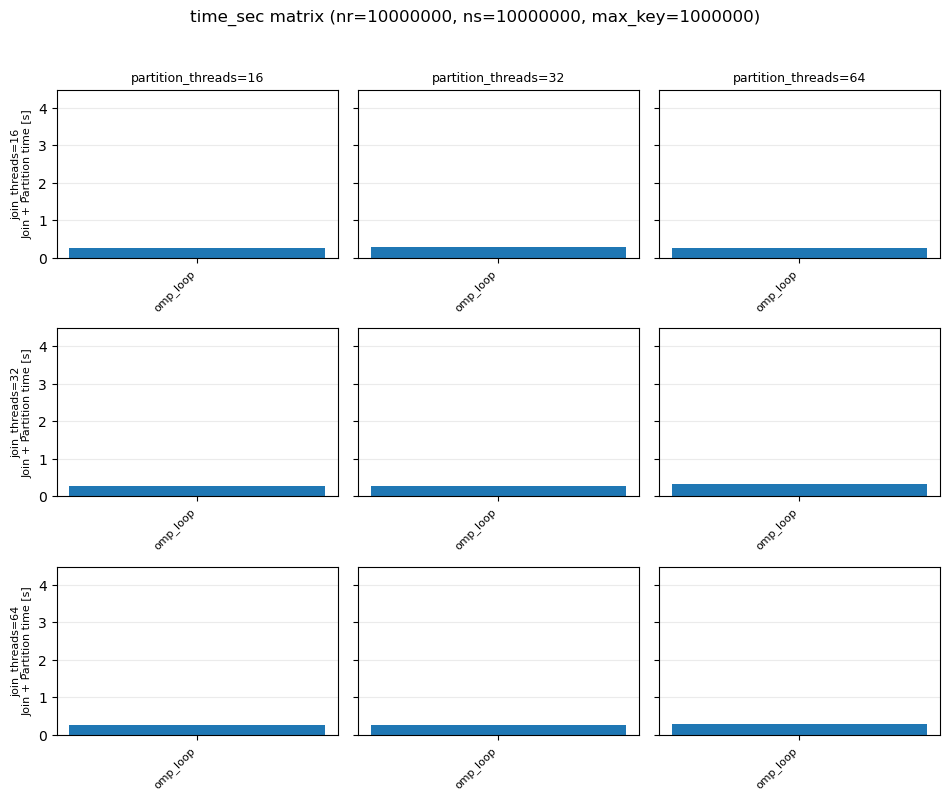

[saved] img/008_time_sec_matrix_nr50000000_ns50000000_maxkey1000000.png


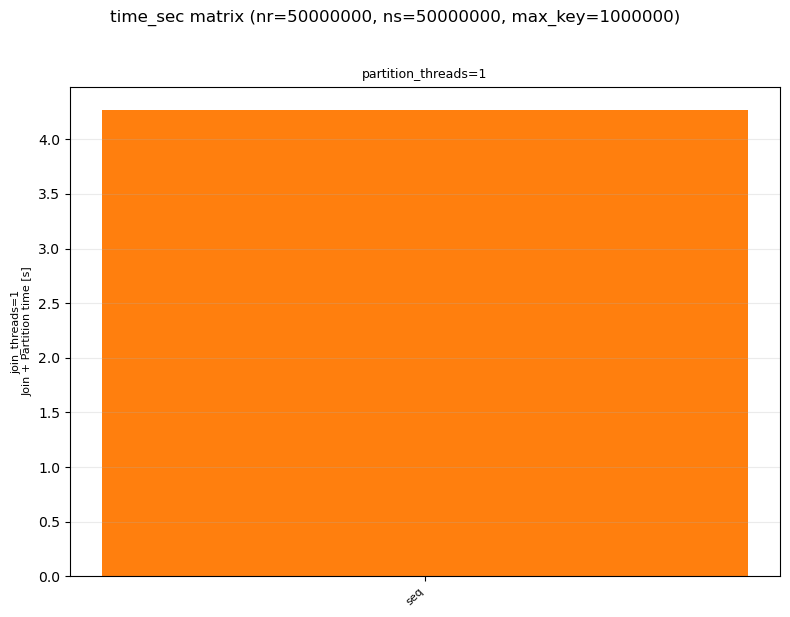

In [62]:
global_tot_time_ymax = stable_avg_df["time_sec"].max()
plot_thread_matrix(
    stable_avg_df,
    metric_col="time_sec",
    y_label="Join + Partition time [s]",
    title_prefix="time_sec",
    global_ymax=global_tot_time_ymax,
)

# Speedup

In [63]:
baseline_exec_type = "seq"

baseline_df = (
    stable_avg_df[stable_avg_df["exec_type"] == baseline_exec_type][
        ["nr", "ns", "max_key", "total_throughput"]
    ]
    .groupby(["nr", "ns", "max_key"], as_index=False)
    .agg(baseline_total_throughput=("total_throughput", "mean"))
)

if baseline_df.empty:
    raise ValueError("No seq baseline available for speedup computation")

speedup_avg_df = stable_avg_df.merge(
    baseline_df,
    on=["nr", "ns", "max_key"],
    how="left",
)

speedup_avg_df["speedup_total_throughput"] = (
    speedup_avg_df["total_throughput"] / speedup_avg_df["baseline_total_throughput"]
)
speedup_avg_df.loc[speedup_avg_df["baseline_total_throughput"] <= 0, "speedup_total_throughput"] = float("nan")

speedup_avg_df.head(10)


,checksum1,checksum2,nr,ns,max_key,exec_type,join_count,join_threads,partition_threads,partition_schedule,...,join_chunk,partition_block_size,join_throughput,join_time,partition_throughput,partition_time,time_sec,total_throughput,baseline_total_throughput,speedup_total_throughput
0,6185417096973469475,16931092769743058723,50000000,50000000,1000000,seq,2499986166,1,1,NaN,...,NaN,NaN,4.320027e+07,2.328505,5.157712e+07,1.938928,4.269839,2.345851e+07,2.345851e+07,1.0
1,7970473340851283408,15465518843320288240,10000000,10000000,1000000,omp_loop,99994796,16,16,dynamic,...,0.0,32768.0,5.500081e+08,0.036363,2.392720e+08,0.083587,0.120602,1.658343e+08,NaN,NaN
2,7970473340851283408,15465518843320288240,10000000,10000000,1000000,omp_loop,99994796,16,16,dynamic,...,0.0,131072.0,5.241828e+08,0.038155,2.421211e+08,0.082603,0.121493,1.646183e+08,NaN,NaN
3,7970473340851283408,15465518843320288240,10000000,10000000,1000000,omp_loop,99994796,16,16,dynamic,...,32.0,32768.0,2.760222e+08,0.072458,2.385954e+08,0.083824,0.157186,1.272379e+08,NaN,NaN
4,7970473340851283408,15465518843320288240,10000000,10000000,1000000,omp_loop,99994796,16,16,dynamic,...,32.0,131072.0,2.787979e+08,0.071737,2.397880e+08,0.083407,0.155900,1.282874e+08,NaN,NaN
5,7970473340851283408,15465518843320288240,10000000,10000000,1000000,omp_loop,99994796,16,16,dynamic,...,0.0,32768.0,5.543426e+08,0.036079,1.940217e+08,0.103081,0.139840,1.430209e+08,NaN,NaN
6,7970473340851283408,15465518843320288240,10000000,10000000,1000000,omp_loop,99994796,16,16,dynamic,...,0.0,131072.0,5.254399e+08,0.038063,8.057011e+07,0.248231,0.287003,6.968568e+07,NaN,NaN
7,7970473340851283408,15465518843320288240,10000000,10000000,1000000,omp_loop,99994796,16,16,dynamic,...,32.0,32768.0,2.794756e+08,0.071563,1.944017e+08,0.102880,0.175326,1.140733e+08,NaN,NaN
8,7970473340851283408,15465518843320288240,10000000,10000000,1000000,omp_loop,99994796,16,16,dynamic,...,32.0,131072.0,2.785524e+08,0.071800,1.089307e+08,0.183603,0.256126,7.808662e+07,NaN,NaN
9,7970473340851283408,15465518843320288240,10000000,10000000,1000000,omp_loop,99994796,16,16,dynamic,...,0.0,32768.0,5.319084e+08,0.037600,2.376866e+08,0.084144,0.122505,1.632586e+08,NaN,NaN


[saved] img/009_speedup_total_throughput_matrix_nr10000000_ns10000000_maxkey1000000.png


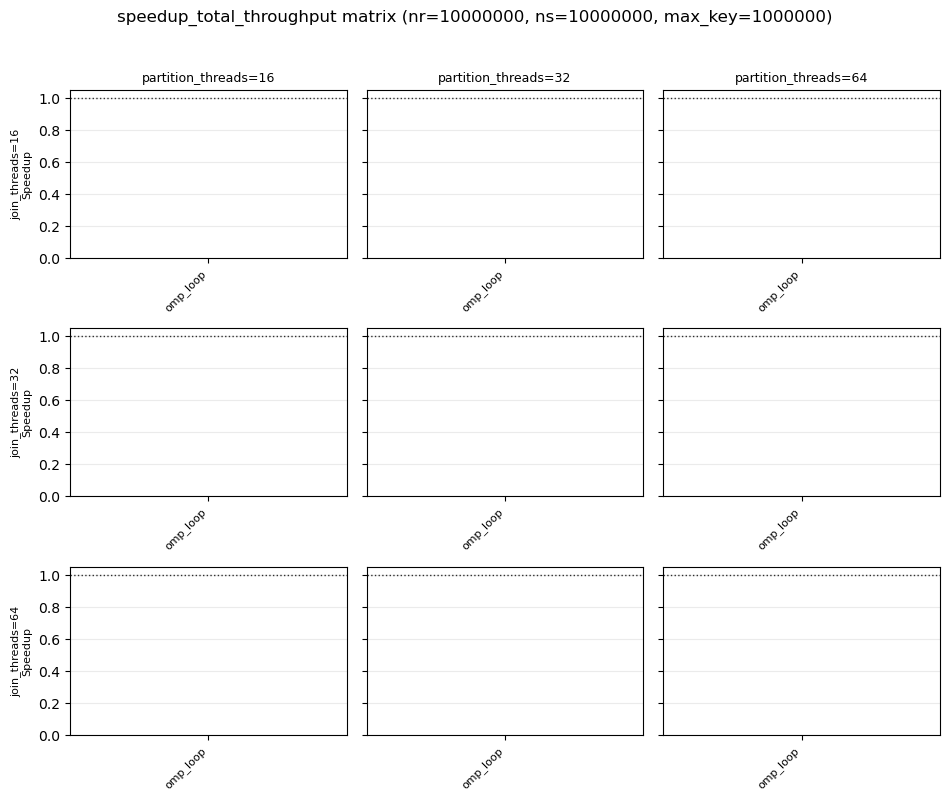

[saved] img/010_speedup_total_throughput_matrix_nr50000000_ns50000000_maxkey1000000.png


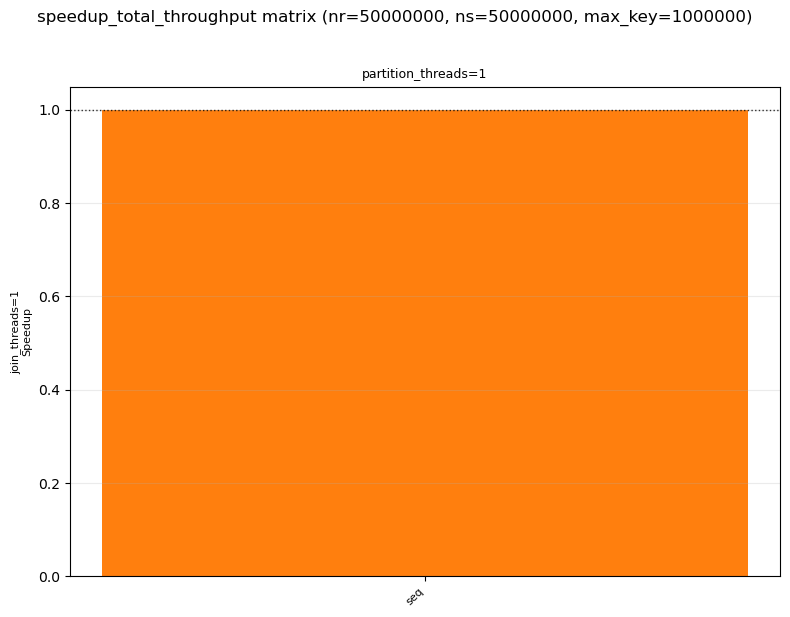

In [64]:
global_speedup_ymax = speedup_avg_df["speedup_total_throughput"].max()
plot_thread_matrix(
    speedup_avg_df,
    metric_col="speedup_total_throughput",
    y_label="Speedup",
    title_prefix="speedup_total_throughput",
    global_ymax=global_speedup_ymax,
    hline=1.0,
)


# Throughput

[saved] img/011_partition_throughput_matrix_nr10000000_ns10000000_maxkey1000000.png


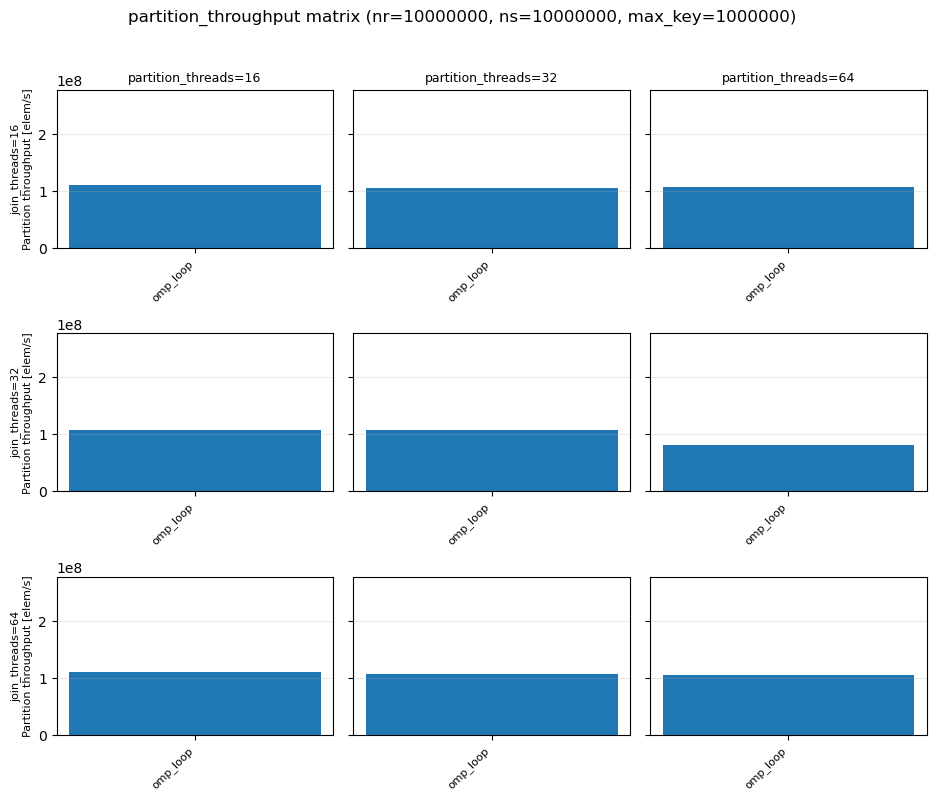

[saved] img/012_partition_throughput_matrix_nr50000000_ns50000000_maxkey1000000.png


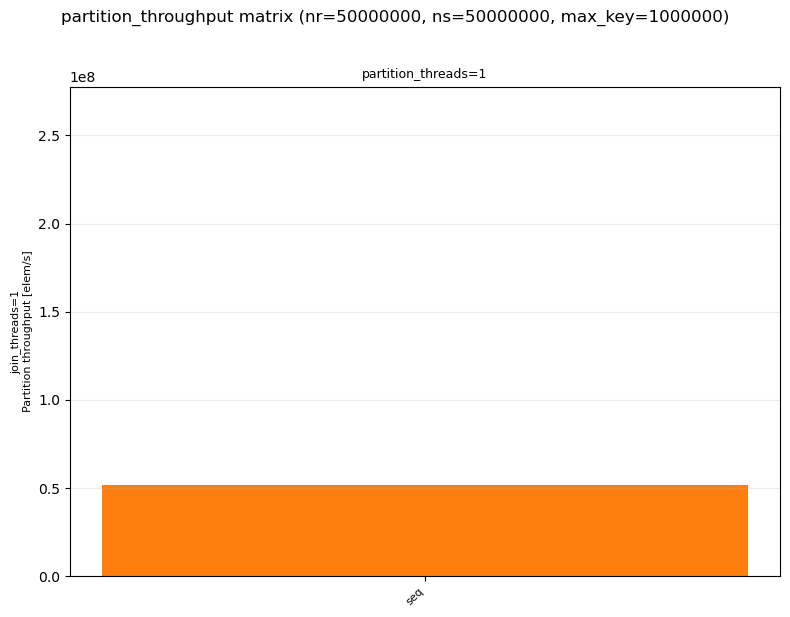

[saved] img/013_join_throughput_matrix_nr10000000_ns10000000_maxkey1000000.png


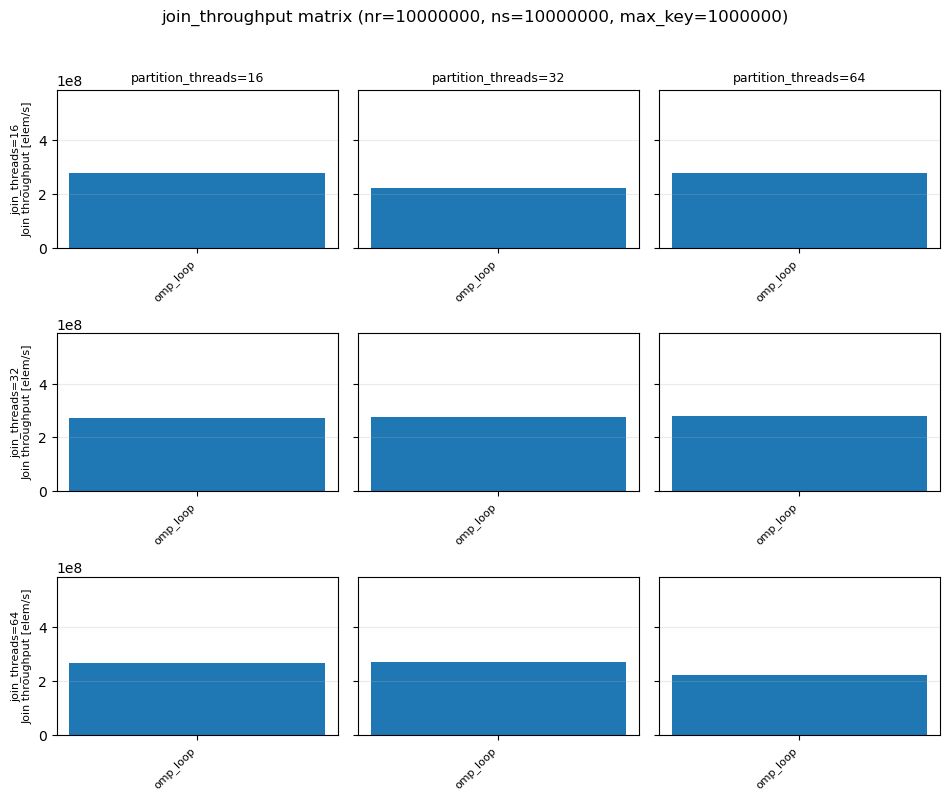

[saved] img/014_join_throughput_matrix_nr50000000_ns50000000_maxkey1000000.png


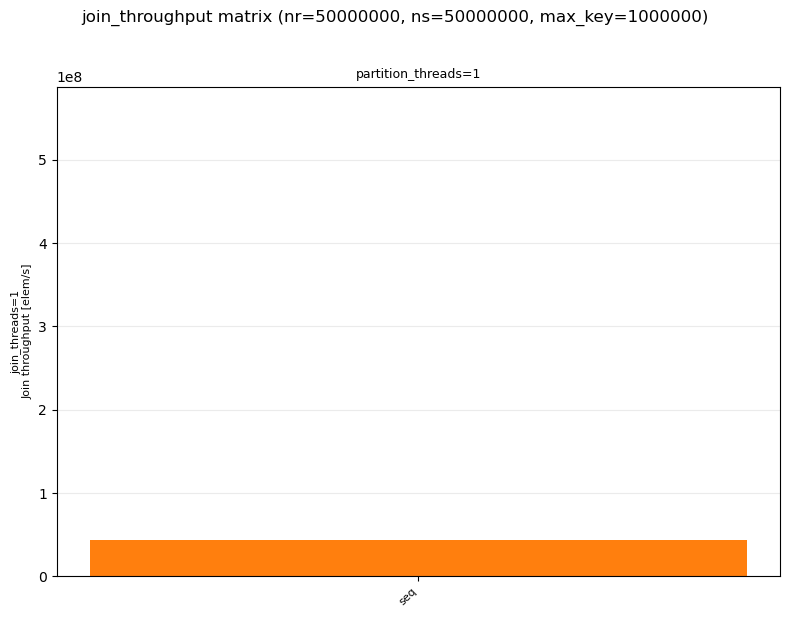

[saved] img/015_total_throughput_matrix_nr10000000_ns10000000_maxkey1000000.png


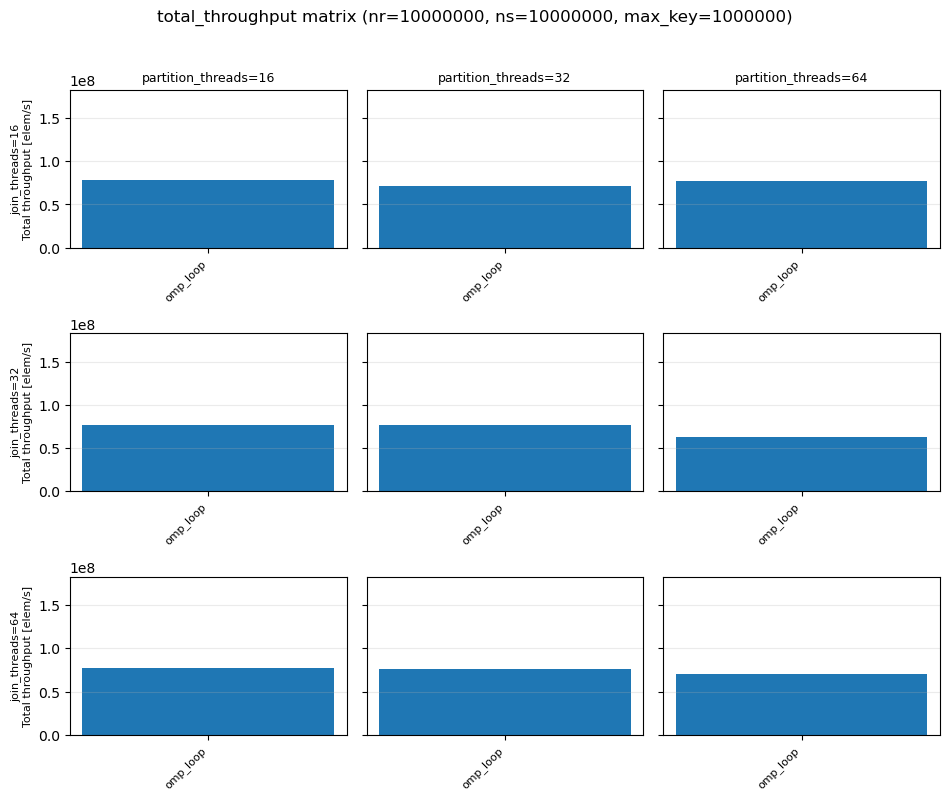

[saved] img/016_total_throughput_matrix_nr50000000_ns50000000_maxkey1000000.png


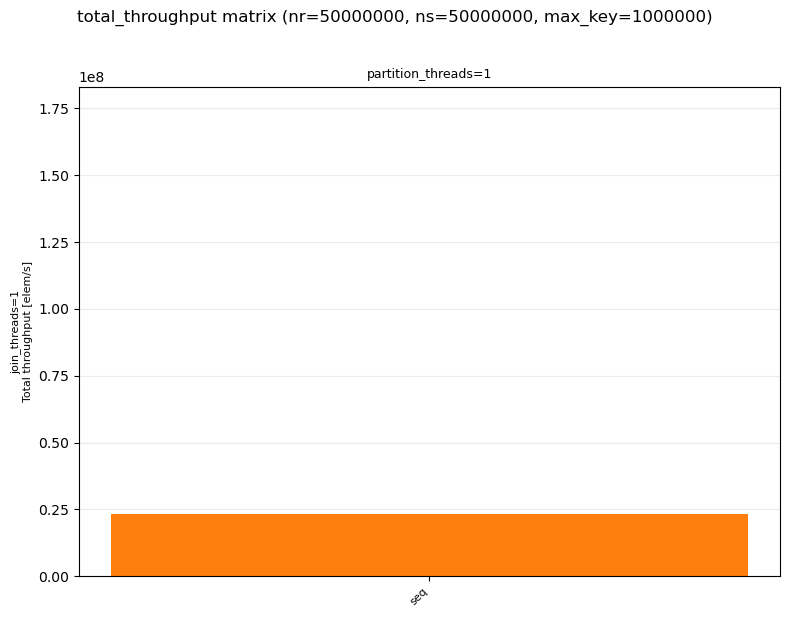

In [65]:
throughput_metrics = [
    ("partition_throughput", "Partition throughput [elem/s]"),
    ("join_throughput", "Join throughput [elem/s]"),
    ("total_throughput", "Total throughput [elem/s]"),
]

for metric_col, ylabel in throughput_metrics:
    if metric_col not in stable_avg_df.columns:
        continue

    global_metric_ymax = stable_avg_df[metric_col].max()
    plot_thread_matrix(
        stable_avg_df,
        metric_col=metric_col,
        y_label=ylabel,
        title_prefix=metric_col,
        global_ymax=global_metric_ymax,
    )
